# Transformer DGA Fault Classification — Dataset Validity & Signal Analysis

**A2 Option 2 — Preliminary Notebook**

## Purpose

This notebook is the first stage of the project. Its purpose is to determine whether the supplied company-provided synthetic DGA dataset contains a meaningful, learnable relationship between DGA measurements and the `fault_by_rogers` target.

We will **not** perform extensive hyperparameter tuning here.

Instead, we will:

1. Load and audit the dataset.
2. Document the dataset structure and target.
3. Identify potential target leakage.
4. Examine whether DGA variables differ across fault classes.
5. Establish a majority-class baseline.
6. Test simple and nonlinear classifiers using stratified cross-validation.
7. Repeat evaluation with permuted labels as a control experiment.
8. Decide whether the dataset provides enough evidence to proceed to the main modelling stage.

> **Confidentiality:** The underlying industrial source data and company identity must not be disclosed. This notebook uses only the synthetic dataset supplied for academic use.

In [1]:
# 2. Environment setup

import sys
import subprocess
import importlib.util

required = {
    "pandas": "pandas",
    "numpy": "numpy",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "sklearn": "scikit-learn",
    "openpyxl": "openpyxl",
    "xgboost": "xgboost",
}

missing = [pip_name for module, pip_name in required.items()
           if importlib.util.find_spec(module) is None]

if missing:
    print("Installing missing packages:", missing)
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

print("Environment ready.")

Environment ready.


In [2]:
# 3. Imports and reproducibility

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    make_scorer,
)
from sklearn.feature_selection import mutual_info_classif
from sklearn.inspection import permutation_importance

from xgboost import XGBClassifier

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Random state:", RANDOM_STATE)

Random state: 42


## 4. Load the dataset

### Expected file

The notebook assumes the uploaded file is:

`dummy_dga_dataset.xlsx`

If using Google Colab, upload the file to the Colab session or change `DATA_PATH` to the location of the uploaded file.

In [3]:
DATA_PATH = "C:\\Users\\srian\\Documents\\GitHub\\32513 31005 Advanced Data Analytics Algorithms, Machine Learning\\Data\\dummy_dga_dataset.xlsx"

df = pd.read_excel(DATA_PATH)

print("Dataset loaded successfully.")
print("Shape:", df.shape)
display(df.head())

Dataset loaded successfully.
Shape: (300, 23)


,row_id,asset,ts_H2,H2,C2H2,C2H4,C2H6,CH4,CO,CO2,...,ts_CH4,ts_CO,ts_CO2,R_C2H2_C2H4,R_CH4_H2,R_C2H4_C2H6,abnormal,triggers,status,fault_by_rogers
0,1,TX_A,2025-01-01 00:00:00,31.390939,0.882090,14.181881,4.206888,13.688683,599.963626,7332.511459,...,2025-01-01 00:00:00,2025-01-01 00:00:00,2025-01-01 00:00:00,0.062198,0.436071,3.371110,False,NaN,Normal,Non-determinable
1,2,TX_B,2025-01-01 01:00:00,35.341884,0.507179,12.612538,6.345830,59.938383,557.168722,7240.401074,...,2025-01-01 01:00:00,2025-01-01 01:00:00,2025-01-01 01:00:00,0.040212,1.695959,1.987532,False,NaN,Normal,Thermal Fault
2,3,TX_C,2025-01-01 02:00:00,65.635357,0.002433,24.096744,7.336242,38.569814,594.269670,9993.446821,...,2025-01-01 02:00:00,2025-01-01 02:00:00,2025-01-01 02:00:00,0.000101,0.587638,3.284617,False,NaN,Normal,Partial Discharge
3,4,TX_B,2025-01-01 03:00:00,12.796451,0.537190,24.218719,16.563508,31.730099,776.015100,8341.712289,...,2025-01-01 03:00:00,2025-01-01 03:00:00,2025-01-01 03:00:00,0.022181,2.479602,1.462173,False,NaN,Normal,Normal
4,5,TX_B,2025-01-01 04:00:00,48.779920,0.435549,22.021012,15.318398,33.244361,665.254346,8202.173810,...,2025-01-01 04:00:00,2025-01-01 04:00:00,2025-01-01 04:00:00,0.019779,0.681517,1.437553,False,NaN,Normal,Non-determinable


In [4]:
# 5. Basic dataset audit

print("Rows:", len(df))
print("Columns:", len(df.columns))
print("\nColumn names:")
for i, col in enumerate(df.columns, start=1):
    print(f"{i:02d}. {col}")

print("\nData types:")
display(df.dtypes.to_frame("dtype"))

print("\nMissing values:")
display(df.isna().sum().sort_values(ascending=False).to_frame("missing"))

print("\nDuplicate rows:", df.duplicated().sum())

Rows: 300
Columns: 23

Column names:
01. row_id
02. asset
03. ts_H2
04. H2
05. C2H2
06. C2H4
07. C2H6
08. CH4
09. CO
10. CO2
11. ts_C2H2
12. ts_C2H4
13. ts_C2H6
14. ts_CH4
15. ts_CO
16. ts_CO2
17. R_C2H2_C2H4
18. R_CH4_H2
19. R_C2H4_C2H6
20. abnormal
21. triggers
22. status
23. fault_by_rogers

Data types:


,dtype
row_id,int64
asset,object
ts_H2,datetime64[ns]
H2,float64
C2H2,float64
C2H4,float64
C2H6,float64
CH4,float64
CO,float64
CO2,float64



Missing values:


,missing
triggers,119
row_id,0
ts_C2H6,0
status,0
abnormal,0
R_C2H4_C2H6,0
R_CH4_H2,0
R_C2H2_C2H4,0
ts_CO2,0
ts_CO,0



Duplicate rows: 0


## 5.1 Target distribution

The main target is `fault_by_rogers`.

We will inspect the class distribution before modelling because accuracy alone can be misleading when class sizes differ.

,count,percentage
fault_by_rogers,,
Normal,87,29.00
Partial Discharge,76,25.33
Thermal Fault,74,24.67
Non-determinable,63,21.00


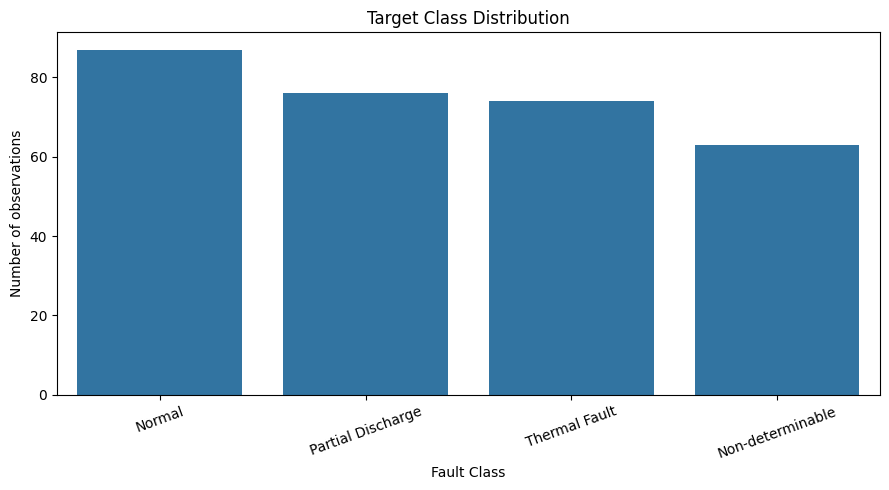

In [5]:
TARGET = "fault_by_rogers"

if TARGET not in df.columns:
    raise KeyError(
        f"'{TARGET}' was not found. Available columns are:\n{df.columns.tolist()}"
    )

target_counts = df[TARGET].value_counts(dropna=False)
target_pct = df[TARGET].value_counts(normalize=True, dropna=False).mul(100).round(2)

target_summary = pd.DataFrame({
    "count": target_counts,
    "percentage": target_pct
})

display(target_summary)

plt.figure(figsize=(9, 5))
sns.countplot(data=df, x=TARGET, order=target_counts.index)
plt.title("Target Class Distribution")
plt.xlabel("Fault Class")
plt.ylabel("Number of observations")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## 6. Column classification

We will explicitly define which variables are allowed to become model inputs.

### Candidate raw DGA features

- H2
- C2H2
- C2H4
- C2H6
- CH4
- CO
- CO2

### Candidate engineered features

- R_C2H2_C2H4
- R_CH4_H2
- R_C2H4_C2H6

### Variables excluded from predictive modelling

- target
- `abnormal`
- `status`
- `triggers`
- identifiers
- asset identifiers
- timestamps, unless a later experiment provides a defensible reason to use them

This conservative feature definition prevents the first experiment from accidentally learning from variables that already encode the target or the abnormality rule.

In [6]:
RAW_DGA = [
    "H2",
    "C2H2",
    "C2H4",
    "C2H6",
    "CH4",
    "CO",
    "CO2",
]

RATIO_FEATURES = [
    "R_C2H2_C2H4",
    "R_CH4_H2",
    "R_C2H4_C2H6",
]

required_features = RAW_DGA + RATIO_FEATURES
missing_features = [c for c in required_features if c not in df.columns]

print("Missing expected DGA features:", missing_features)

if missing_features:
    print("\nAvailable columns:")
    print(df.columns.tolist())
else:
    print("\nAll expected DGA features are present.")

FEATURE_SET_RAW = RAW_DGA
FEATURE_SET_RAW_RATIOS = RAW_DGA + RATIO_FEATURES
FEATURE_SET_RATIOS = RATIO_FEATURES

print("\nRaw DGA:", FEATURE_SET_RAW)
print("Raw + ratios:", FEATURE_SET_RAW_RATIOS)
print("Ratios only:", FEATURE_SET_RATIOS)

Missing expected DGA features: []

All expected DGA features are present.

Raw DGA: ['H2', 'C2H2', 'C2H4', 'C2H6', 'CH4', 'CO', 'CO2']
Raw + ratios: ['H2', 'C2H2', 'C2H4', 'C2H6', 'CH4', 'CO', 'CO2', 'R_C2H2_C2H4', 'R_CH4_H2', 'R_C2H4_C2H6']
Ratios only: ['R_C2H2_C2H4', 'R_CH4_H2', 'R_C2H4_C2H6']


# 7. Leakage investigation

Before training, inspect variables that may already encode the abnormality decision.

The dataset contains:

- `abnormal`
- `status`
- `triggers`

These are **not model inputs**.

We will inspect their relationships with the DGA measurements and the target to document why they are excluded.

In [7]:
leakage_candidates = [c for c in ["abnormal", "status", "triggers"] if c in df.columns]

for col in leakage_candidates:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False))


--- abnormal ---
abnormal
True     181
False    119
Name: count, dtype: int64

--- status ---
status
Abnormal    181
Normal      119
Name: count, dtype: int64

--- triggers ---
triggers
C2H4 > 60    181
NaN          119
Name: count, dtype: int64


In [8]:
# Check whether abnormality is exactly determined by C2H4 > 60.
if "abnormal" in df.columns and "C2H4" in df.columns:
    rule = df["C2H4"] > 60
    abnormal_bool = df["abnormal"].astype(bool)

    print("Rows where (C2H4 > 60) disagrees with abnormal:", (rule != abnormal_bool).sum())
    print("Rows where C2H4 > 60:", rule.sum())
    print("Rows marked abnormal:", abnormal_bool.sum())

Rows where (C2H4 > 60) disagrees with abnormal: 0
Rows where C2H4 > 60: 181
Rows marked abnormal: 181


In [9]:
# Cross-tabs for existing labels/status/trigger relationships
for col in ["abnormal", "status", "triggers"]:
    if col in df.columns:
        print(f"\nCross-tab: {col} vs {TARGET}")
        display(pd.crosstab(df[col], df[TARGET], margins=True))


Cross-tab: abnormal vs fault_by_rogers


fault_by_rogers,Non-determinable,Normal,Partial Discharge,Thermal Fault,All
abnormal,,,,,
False,25,32,32,30,119
True,38,55,44,44,181
All,63,87,76,74,300



Cross-tab: status vs fault_by_rogers


fault_by_rogers,Non-determinable,Normal,Partial Discharge,Thermal Fault,All
status,,,,,
Abnormal,38,55,44,44,181
Normal,25,32,32,30,119
All,63,87,76,74,300



Cross-tab: triggers vs fault_by_rogers


fault_by_rogers,Non-determinable,Normal,Partial Discharge,Thermal Fault,All
triggers,,,,,
C2H4 > 60,38,55,44,44,181
All,38,55,44,44,181


### Leakage decision

If a variable directly encodes an existing rule or the target, it is excluded from predictive modelling.

This is important because a model that receives `status`, `abnormal`, or `triggers` would not be solving the intended deployment problem:

> **DGA measurements → predicted transformer condition**

# 8. DGA feature distributions by fault class

The first evidence of learnability should come from the feature distributions.

If the same DGA measurement has substantially different distributions across fault classes, that provides a reason to expect a classifier may learn useful boundaries.

If the distributions strongly overlap, classification may be intrinsically difficult.

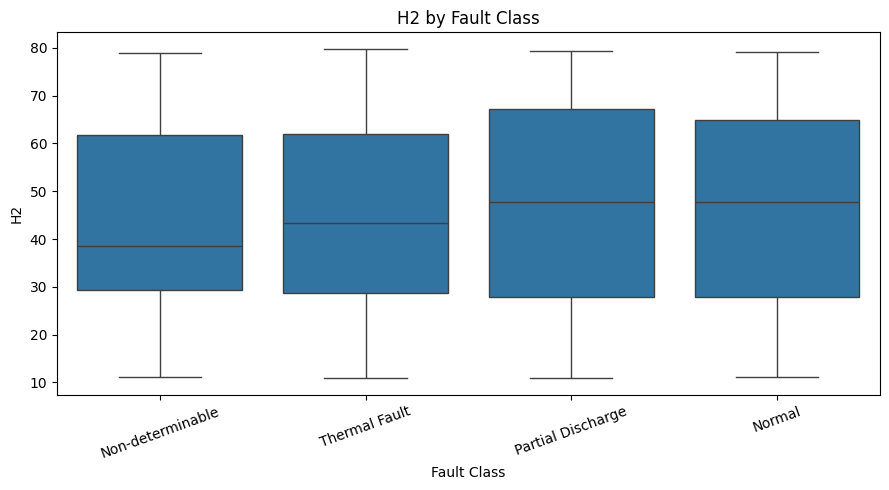

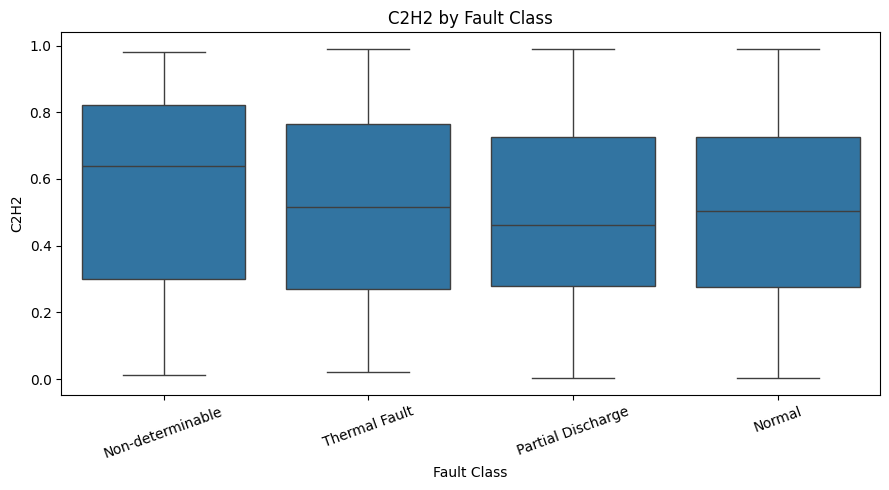

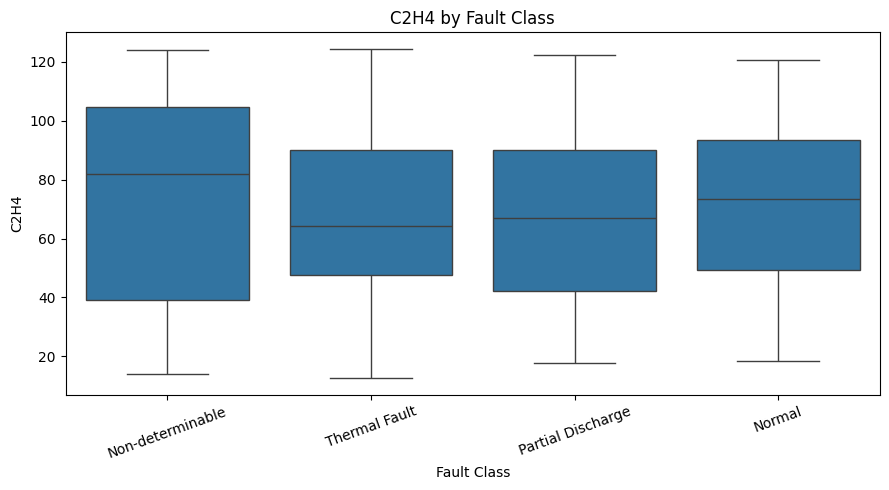

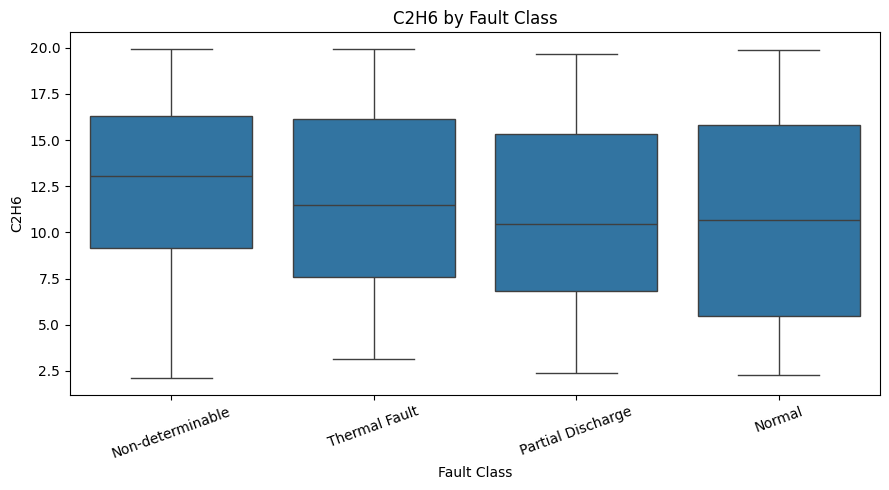

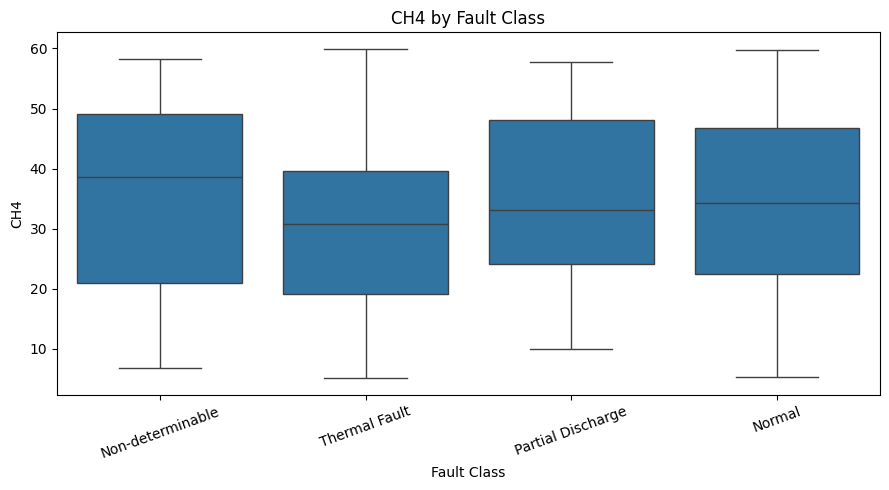

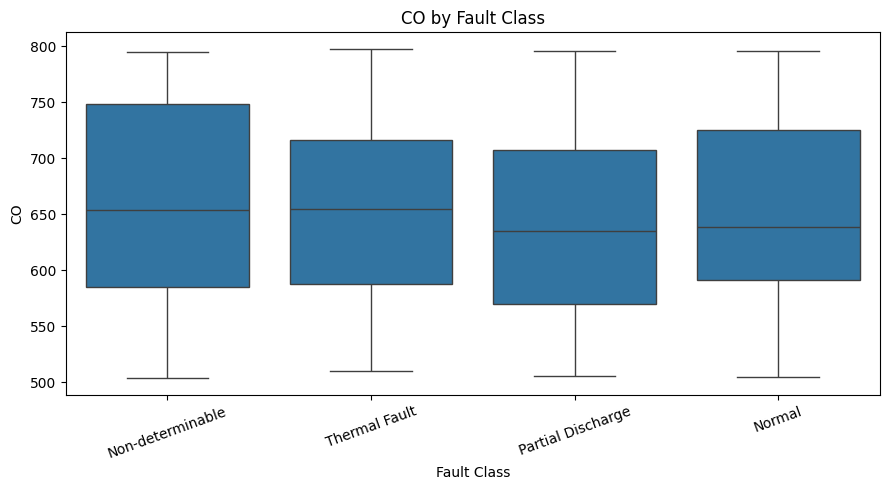

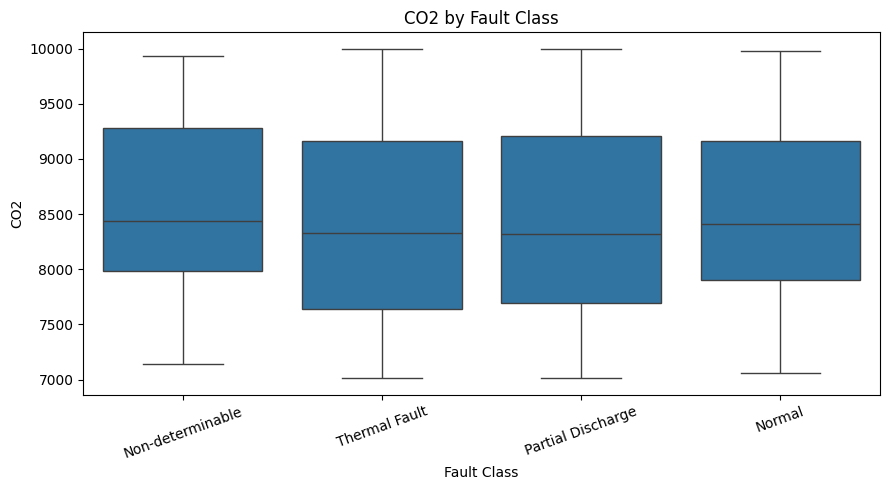

In [10]:
for feature in RAW_DGA:
    plt.figure(figsize=(9, 5))
    sns.boxplot(data=df, x=TARGET, y=feature)
    plt.title(f"{feature} by Fault Class")
    plt.xlabel("Fault Class")
    plt.ylabel(feature)
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()

In [11]:
# Class-wise summary statistics for raw DGA features
class_means = df.groupby(TARGET)[RAW_DGA].mean().T
class_medians = df.groupby(TARGET)[RAW_DGA].median().T

print("Class-wise means:")
display(class_means)

print("Class-wise medians:")
display(class_medians)

Class-wise means:


fault_by_rogers,Non-determinable,Normal,Partial Discharge,Thermal Fault
H2,44.382219,46.594140,47.250810,44.538473
C2H2,0.563194,0.515831,0.494955,0.524535
C2H4,71.893892,72.363188,67.464728,69.233158
C2H6,12.243670,10.933862,10.712384,11.640387
CH4,35.368327,34.181643,34.568784,30.471259
CO,657.050503,651.064234,640.927190,652.524954
CO2,8542.149948,8475.441637,8415.332721,8374.843701


Class-wise medians:


fault_by_rogers,Non-determinable,Normal,Partial Discharge,Thermal Fault
H2,38.436584,47.674195,47.818958,43.443314
C2H2,0.639381,0.504870,0.463090,0.515489
C2H4,82.059462,73.467360,67.128573,64.240673
C2H6,13.074650,10.649907,10.466028,11.495851
CH4,38.621003,34.287690,33.053380,30.805900
CO,654.166593,638.863050,635.026738,654.365792
CO2,8438.905442,8410.663135,8321.172294,8324.384421


## 8.1 Correlation structure

Correlation does not prove predictive usefulness, but it can reveal redundant variables and relationships between the DGA measurements.

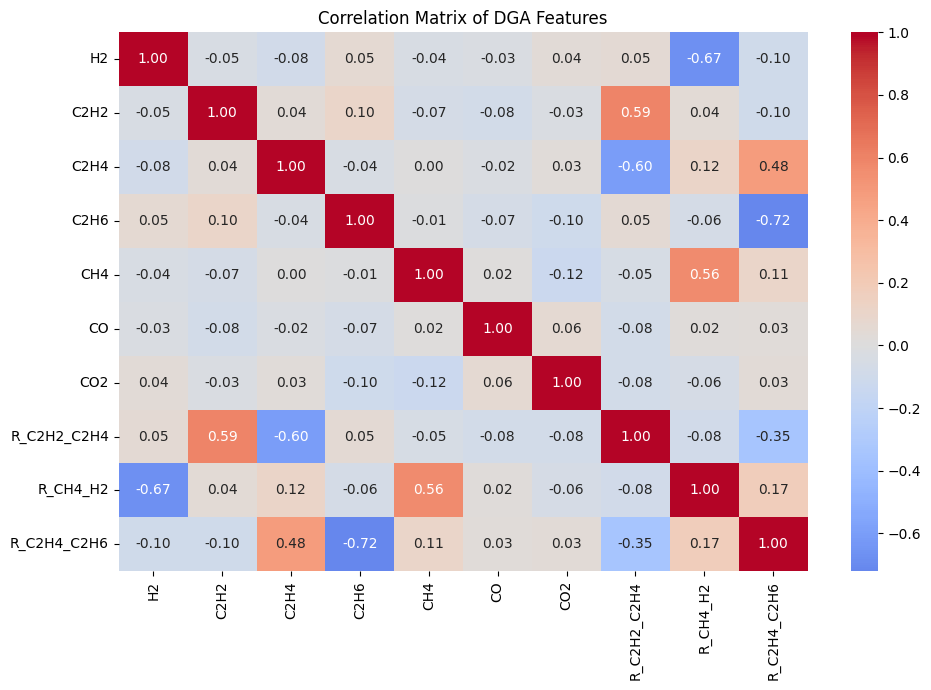

In [12]:
plt.figure(figsize=(10, 7))
sns.heatmap(df[RAW_DGA + RATIO_FEATURES].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix of DGA Features")
plt.tight_layout()
plt.show()

# 9. Mutual information screening

Mutual information provides a non-linear dependence measure between each feature and the target.

It is **not** a final feature-selection method here.

Its purpose is diagnostic:

> Is there measurable dependence between individual DGA variables and the fault labels?

,feature,mutual_information
0,C2H4,0.051570
1,CH4,0.039237
2,H2,0.021735
3,CO,0.004997
4,C2H2,0.000000
5,C2H6,0.000000
6,CO2,0.000000
7,R_C2H2_C2H4,0.000000
8,R_CH4_H2,0.000000
9,R_C2H4_C2H6,0.000000


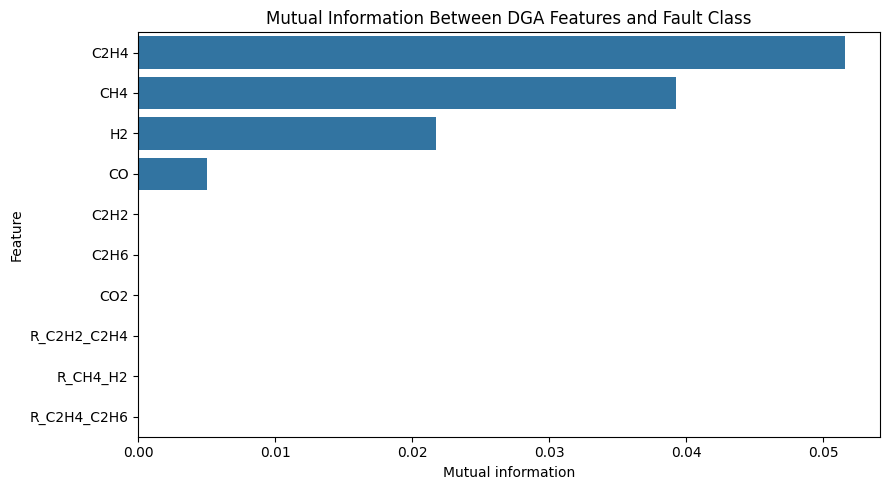

In [13]:
X_mi = df[FEATURE_SET_RAW_RATIOS].copy()
y_mi = df[TARGET].copy()

# Encode target only for the MI calculation.
le = LabelEncoder()
y_encoded = le.fit_transform(y_mi)

mi_values = mutual_info_classif(
    X_mi,
    y_encoded,
    random_state=RANDOM_STATE
)

mi_summary = (
    pd.DataFrame({
        "feature": X_mi.columns,
        "mutual_information": mi_values
    })
    .sort_values("mutual_information", ascending=False)
    .reset_index(drop=True)
)

display(mi_summary)

plt.figure(figsize=(9, 5))
sns.barplot(data=mi_summary, x="mutual_information", y="feature")
plt.title("Mutual Information Between DGA Features and Fault Class")
plt.xlabel("Mutual information")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# 10. Baseline evaluation

We now establish the minimum performance that a useful classifier should beat.

### Baseline

A `DummyClassifier` always predicts the most frequent class.

### Main diagnostic models

1. Multiclass Logistic Regression — relatively simple model.
2. Extra Trees — nonlinear tree ensemble.
3. XGBoost — nonlinear gradient-boosted tree model.

At this stage we are testing **learnability**, not optimising the final model.

In [14]:
X = df[FEATURE_SET_RAW_RATIOS].copy()
y = df[TARGET].copy()

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

scoring = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "macro_f1": make_scorer(f1_score, average="macro"),
    "weighted_f1": make_scorer(f1_score, average="weighted"),
}

models = {
    "Majority baseline": Pipeline([
        ("model", DummyClassifier(strategy="most_frequent"))
    ]),

    "Logistic Regression": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=3000,
            random_state=RANDOM_STATE
        ))
    ]),

    "Extra Trees": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", ExtraTreesClassifier(
            n_estimators=300,
            random_state=RANDOM_STATE,
            class_weight="balanced"
        ))
    ]),
}

results = []

for name, model in models.items():
    scores = cross_validate(
        model,
        X,
        y,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=True
    )

    results.append({
        "model": name,
        "cv_accuracy_mean": scores["test_accuracy"].mean(),
        "cv_accuracy_std": scores["test_accuracy"].std(),
        "cv_macro_f1_mean": scores["test_macro_f1"].mean(),
        "cv_macro_f1_std": scores["test_macro_f1"].std(),
        "cv_weighted_f1_mean": scores["test_weighted_f1"].mean(),
        "cv_weighted_f1_std": scores["test_weighted_f1"].std(),
        "cv_balanced_accuracy_mean": scores["test_balanced_accuracy"].mean(),
        "cv_balanced_accuracy_std": scores["test_balanced_accuracy"].std(),
        "train_macro_f1_mean": scores["train_macro_f1"].mean(),
    })

baseline_results = pd.DataFrame(results).sort_values(
    "cv_macro_f1_mean",
    ascending=False
)

display(baseline_results)

,model,cv_accuracy_mean,cv_accuracy_std,cv_macro_f1_mean,cv_macro_f1_std,cv_weighted_f1_mean,cv_weighted_f1_std,cv_balanced_accuracy_mean,cv_balanced_accuracy_std,train_macro_f1_mean
2,Extra Trees,0.25,0.044721,0.240368,0.042606,0.244701,0.043096,0.243368,0.043539,1.000000
1,Logistic Regression,0.24,0.055377,0.224475,0.053285,0.227980,0.055610,0.236107,0.054213,0.357135
0,Majority baseline,0.29,0.008165,0.112388,0.002447,0.130450,0.006542,0.250000,0.000000,0.112402


# 11. Feature-representation experiment

The broader project asks whether engineered DGA ratios add useful information.

We will therefore compare:

- Raw DGA only
- Raw DGA + ratios
- Ratios only

using the same model and the same cross-validation strategy.

This is a controlled experiment: the validation procedure and model family remain constant while the representation changes.

In [15]:
representation_sets = {
    "Raw DGA": FEATURE_SET_RAW,
    "Raw + ratios": FEATURE_SET_RAW_RATIOS,
    "Ratios only": FEATURE_SET_RATIOS,
}

representation_results = []

for feature_name, features in representation_sets.items():
    X_rep = df[features]

    model = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", ExtraTreesClassifier(
            n_estimators=300,
            random_state=RANDOM_STATE,
            class_weight="balanced"
        ))
    ])

    scores = cross_validate(
        model,
        X_rep,
        y,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    representation_results.append({
        "feature_representation": feature_name,
        "macro_f1_mean": scores["test_macro_f1"].mean(),
        "macro_f1_std": scores["test_macro_f1"].std(),
        "accuracy_mean": scores["test_accuracy"].mean(),
        "balanced_accuracy_mean": scores["test_balanced_accuracy"].mean(),
    })

representation_results = pd.DataFrame(representation_results)
display(representation_results)

,feature_representation,macro_f1_mean,macro_f1_std,accuracy_mean,balanced_accuracy_mean
0,Raw DGA,0.248507,0.047529,0.256667,0.250804
1,Raw + ratios,0.240368,0.042606,0.250000,0.243368
2,Ratios only,0.173790,0.033983,0.186667,0.177385


# 12. XGBoost signal check

XGBoost is the main candidate model for the eventual project, but here it is used only as another test of whether nonlinear relationships can be learned.

The hyperparameters are deliberately conservative rather than extensively tuned.

In [16]:
# Encode target labels for XGBoost.
target_encoder = LabelEncoder()
y_xgb = target_encoder.fit_transform(y)

xgb_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", XGBClassifier(
        objective="multi:softprob",
        num_class=len(target_encoder.classes_),
        n_estimators=150,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=1.0,
        eval_metric="mlogloss",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        tree_method="hist"
    ))
])

xgb_scores = cross_validate(
    xgb_model,
    X,
    y_xgb,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
    return_train_score=True
)

xgb_summary = pd.DataFrame([{
    "model": "XGBoost",
    "cv_accuracy_mean": xgb_scores["test_accuracy"].mean(),
    "cv_accuracy_std": xgb_scores["test_accuracy"].std(),
    "cv_macro_f1_mean": xgb_scores["test_macro_f1"].mean(),
    "cv_macro_f1_std": xgb_scores["test_macro_f1"].std(),
    "cv_weighted_f1_mean": xgb_scores["test_weighted_f1"].mean(),
    "cv_weighted_f1_std": xgb_scores["test_weighted_f1"].std(),
    "cv_balanced_accuracy_mean": xgb_scores["test_balanced_accuracy"].mean(),
    "cv_balanced_accuracy_std": xgb_scores["test_balanced_accuracy"].std(),
    "train_macro_f1_mean": xgb_scores["train_macro_f1"].mean(),
}])

display(xgb_summary)

,model,cv_accuracy_mean,cv_accuracy_std,cv_macro_f1_mean,cv_macro_f1_std,cv_weighted_f1_mean,cv_weighted_f1_std,cv_balanced_accuracy_mean,cv_balanced_accuracy_std,train_macro_f1_mean
0,XGBoost,0.243333,0.022608,0.239472,0.022179,0.24298,0.021221,0.23876,0.021775,0.994305


# 13. Permutation-label control experiment

This is a key validity check.

We keep the DGA features unchanged but randomly permute the target labels.

If the real-label model performs substantially better than models trained on permuted labels, that supports the conclusion that the DGA variables contain information related to the target.

If real-label and permuted-label performance are similar, there is little evidence of learnable signal.

This is a **control experiment**, not a replacement for proper validation.

Real-label mean macro-F1: 0.2395
Permuted-label mean macro-F1: 0.2438
Permuted-label std: 0.0352
Permuted-label 95th percentile: 0.3001


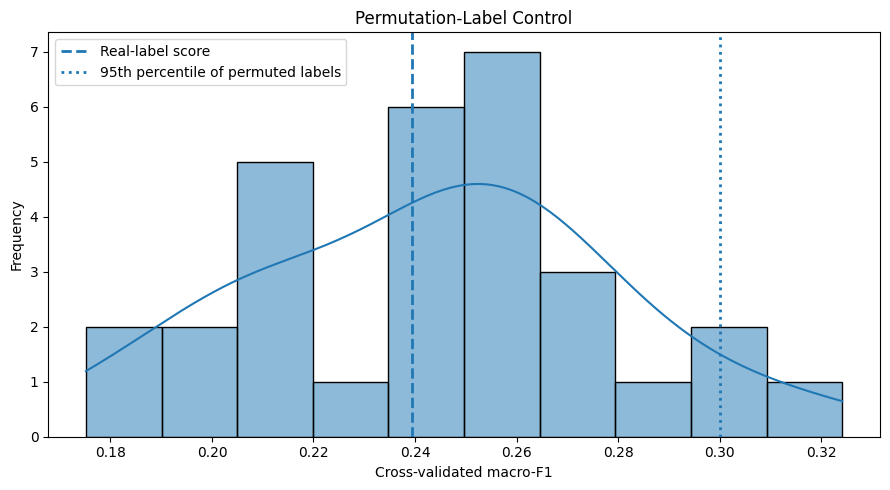

In [17]:
N_PERMUTATIONS = 30

permutation_scores = []

for seed in range(RANDOM_STATE, RANDOM_STATE + N_PERMUTATIONS):
    rng = np.random.default_rng(seed)
    y_perm = rng.permutation(y_xgb)

    scores = cross_validate(
        xgb_model,
        X,
        y_perm,
        cv=cv,
        scoring=make_scorer(f1_score, average="macro"),
        n_jobs=-1
    )

    permutation_scores.append(scores["test_score"].mean())

permutation_scores = np.array(permutation_scores)

real_macro_f1 = xgb_summary.loc[0, "cv_macro_f1_mean"]

print(f"Real-label mean macro-F1: {real_macro_f1:.4f}")
print(f"Permuted-label mean macro-F1: {permutation_scores.mean():.4f}")
print(f"Permuted-label std: {permutation_scores.std():.4f}")
print(f"Permuted-label 95th percentile: {np.percentile(permutation_scores, 95):.4f}")

plt.figure(figsize=(9, 5))
sns.histplot(permutation_scores, bins=10, kde=True)
plt.axvline(real_macro_f1, linestyle="--", linewidth=2, label="Real-label score")
plt.axvline(np.percentile(permutation_scores, 95), linestyle=":", linewidth=2,
            label="95th percentile of permuted labels")
plt.title("Permutation-Label Control")
plt.xlabel("Cross-validated macro-F1")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

# 14. Train-vs-validation gap

A model can achieve a high training score simply by memorising the training data.

We therefore compare training and validation macro-F1.

A large gap is evidence of overfitting and will affect how we interpret the model.

In [ ]:
gap_table = pd.DataFrame([{
    "model": "XGBoost",
    "train_macro_f1": xgb_scores["train_macro_f1"].mean(),
    "validation_macro_f1": xgb_scores["test_macro_f1"].mean(),
    "generalisation_gap": (
        xgb_scores["train_macro_f1"].mean()
        - xgb_scores["test_macro_f1"].mean()
    )
}])

display(gap_table)

,model,train_macro_f1,validation_macro_f1,generalisation_gap
0,XGBoost,0.994305,0.239472,0.754834


# 15. Preliminary GO / NO-GO decision

The decision is deliberately evidence-based.

### GO

Proceed to the full project if:

1. The real-label model performs meaningfully above the majority baseline, **and**
2. Real-label performance is clearly above the permutation-label control, **and**
3. The model does not rely only on extreme overfitting.

### INVESTIGATE

If there is some evidence of signal but the result is weak or unstable, investigate:

- class overlap
- feature representation
- validation design
- synthetic-data generation
- target quality

### NO-GO / DATA REVIEW

If real-label performance is approximately the same as the permutation control, do not spend time on extensive hyperparameter tuning.

Instead, review the synthetic-data generation process with the data provider.

> This is not a failure of the ML project. Demonstrating that the available representation does not contain sufficient predictive information is itself an important validity finding. The problem would be claiming strong predictive performance when the evidence does not support it.

In [23]:
# 16. Automated preliminary decision

majority_f1 = baseline_results.loc[
    baseline_results["model"] == "Majority baseline",
    "cv_macro_f1_mean"
].iloc[0]

real_score = float(real_macro_f1)
perm_mean = float(permutation_scores.mean())
perm_p95 = float(np.percentile(permutation_scores, 95))
train_score = float(xgb_scores["train_macro_f1"].mean())

print("========== PRELIMINARY DATASET VALIDITY DECISION ==========")
print(f"Majority baseline macro-F1 : {majority_f1:.4f}")
print(f"Real-label XGBoost macro-F1: {real_score:.4f}")
print(f"Permutation mean macro-F1  : {perm_mean:.4f}")
print(f"Permutation 95th percentile: {perm_p95:.4f}")
print(f"XGBoost training macro-F1  : {train_score:.4f}")
print(f"Generalisation gap         : {train_score - real_score:.4f}")
print()

beats_baseline = real_score > majority_f1
beats_permutation = real_score > perm_p95

if beats_baseline and beats_permutation:
    print("DECISION: GO — evidence of learnable signal.")
elif beats_baseline or beats_permutation:
    print("DECISION: INVESTIGATE — some evidence exists, but it is not yet strong enough for a confident GO.")
else:
    print("DECISION: DATA REVIEW — current evidence does not demonstrate useful learnable signal.")

========== PRELIMINARY DATASET VALIDITY DECISION ==========
Majority baseline macro-F1 : 0.1124
Real-label XGBoost macro-F1: 0.2395
Permutation mean macro-F1  : 0.2438
Permutation 95th percentile: 0.3001
XGBoost training macro-F1  : 0.9943
Generalisation gap         : 0.7548

DECISION: INVESTIGATE — some evidence exists, but it is not yet strong enough for a confident GO.
